# Supplementary Figure S3: RyR under-expression without ER calcium overload


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

from plot_config import (
    get_condition,
    apply_style,
    strip_spines,
    label_panel,
    set_n_ticks,
    save_figure,
)

apply_style()


In [2]:
# ============================================================
# CONFIG -- train stimulus (20 pulses, 20 Hz), 3 conditions
# ============================================================

TRAIN_DIRS = {
    "control": Path(
        "/data/hdrive/phd/results/train/ERblocked_comparison/RSV80C250uM_20_p20hz_8_10_serca"
    ),
    "ad_half_ryr_er250": Path(
        "/data/hdrive/phd/results/train/ERblocked_comparison/RSV80C250uM_20_p20hz_8_10_serca_RyRunder"
    ),
    "ad_half_ryr_er250_er_blocked": Path(
        "/data/hdrive/phd/results/train/ERblocked_comparison/RSV80C250uM_20_p20hz_8_10_serca_RyRunder_RSB"
    ),
}
TRAIN_ORDER = ["control", "ad_half_ryr_er250", "ad_half_ryr_er250_er_blocked"]

RING_MARK_CONDITIONS = ["control", "ad_half_ryr_er250"]

N_PULSES = 20
FREQ_HZ = 20
FIRST_PULSE_TIME = 0.002  # s
ISI_S = 1.0 / FREQ_HZ

MARKERSIZE = 6
CAPSIZE = 3
ELINEWIDTH = 1.2
N_TICKS = 3
PULSE_XTICKS = [1, N_PULSES // 2, N_PULSES]

pulses = np.arange(1, N_PULSES + 1)

X_TICKS = {k: PULSE_XTICKS for k in ["fac_vs_pulse", "pr_vs_pulse", "er_peak"]}
X_TICKS["ryr_flux"] = None
Y_TICKS = {k: None for k in ["fac_vs_pulse", "pr_vs_pulse", "er_peak", "ryr_flux"]}

In [3]:
# ============================================================
# DATA LOADING -- functions (reused verbatim from fig7_ER_hyperactivity.ipynb)
# ============================================================


def load_trace(fname):
    """Return (time_s, value) for a two-column whitespace-delimited trace."""
    data = np.loadtxt(fname)
    return data[:, 0], data[:, 1]


def load_ryr_flux(fname):
    """ryrCaFlux.dat: col0=time(s), col1=outflux, col2=influx (molecules/s).
    Net flux = outflux - influx."""
    data = np.loadtxt(fname)
    t = data[:, 0]
    net = data[:, 1] - data[:, 2]
    return t, net


def load_result_auto(fname):
    """Load a `result` file in either known layout, detecting which from its
    shape and validating the decoded values before returning them."""
    data = np.loadtxt(fname)
    if data.shape == (2, 40):
        means, stds = data[0], data[1]
        out = {"pr_mean": means[:20], "pr_sd": stds[:20],
               "fac_mean": means[20:], "fac_sd": stds[20:]}
    elif data.shape == (20, 5):
        out = {"pr_mean": data[:, 1], "pr_sd": data[:, 2],
               "fac_mean": data[:, 3], "fac_sd": data[:, 4]}
    else:
        raise ValueError(f"{fname}: unrecognised result shape {data.shape}")

    pr, fac = out["pr_mean"], out["fac_mean"]
    if pr.min() < 0 or pr.max() > 1:
        raise ValueError(
            f"{fname}: decoded release probability outside [0, 1] "
            f"(range {pr.min():.3f}-{pr.max():.3f}) -- shape matched "
            f"{data.shape} but the column layout does not."
        )
    if abs(fac[0] - 1.0) > 1e-6:
        raise ValueError(
            f"{fname}: decoded facilitation[0] = {fac[0]:.3f}, expected "
            "exactly 1.0 -- column layout does not match this shape."
        )
    return out


def load_ptp(fname):
    """ptp file: 20 values, Pr[i]/Pr[0] per pulse."""
    return np.loadtxt(fname)


def _pulse_windows(first_pulse_time, freq, n_pulses, t_end):
    isi = 1.0 / freq
    starts = first_pulse_time + np.arange(n_pulses) * isi
    ends = np.append(starts[1:], t_end)
    return starts, ends


def extract_pulse_peaks(time, trace, first_pulse_time, freq, n_pulses):
    starts, ends = _pulse_windows(first_pulse_time, freq, n_pulses, time[-1])
    peaks = []
    for t0, t1 in zip(starts, ends):
        mask = (time >= t0) & (time < t1)
        peaks.append(np.max(trace[mask]) if np.any(mask) else np.nan)
    return np.asarray(peaks)


def extract_pulse_baselines(time, trace, first_pulse_time, freq, n_pulses):
    starts, _ = _pulse_windows(first_pulse_time, freq, n_pulses, time[-1])
    baselines = []
    for t0 in starts:
        idx = max(np.searchsorted(time, t0) - 1, 0)
        baselines.append(trace[idx])
    return np.asarray(baselines)


In [4]:
# ============================================================
# FIGURE-BUILDING HELPERS (reused verbatim from fig7_ER_hyperactivity.ipynb)
# ============================================================


def apply_xticks(ax, key, vmin, vmax, ticks=None):
    ticks = ticks if ticks is not None else X_TICKS
    override = ticks.get(key)
    if override is not None:
        ax.set_xticks(override)
    else:
        set_n_ticks(ax, vmin, vmax, n=N_TICKS, axis="x")


def apply_yticks(ax, key, vmin, vmax, ticks=None):
    ticks = ticks if ticks is not None else Y_TICKS
    override = ticks.get(key)
    if override is not None:
        ax.set_yticks(override)
        pad = 0.05 * (max(override) - min(override))
        ax.set_ylim(min(override) - pad, max(override) + pad)
    else:
        set_n_ticks(ax, vmin, vmax, n=N_TICKS, axis="y")


def trace_panel(ax, letter, field, ylabel, tick_key, keys=None, y_range=None,
                 letter_y=1.05, data=None, ticks_x=None, ticks_y=None):
    data = data if data is not None else train_data
    keys = keys if keys is not None else TRAIN_ORDER
    for key in keys:
        cond = get_condition(key)
        ax.plot(
            pulses, data[key][field],
            color=cond.color, linestyle="-", marker=cond.marker,
            markersize=MARKERSIZE, markerfacecolor=cond.color, markeredgecolor=cond.color,
            alpha=cond.alpha, zorder=cond.zorder,
        )
    ax.set_xlabel("Pulse Number")
    ax.set_ylabel(ylabel)
    apply_xticks(ax, tick_key, pulses.min(), pulses.max(), ticks=ticks_x)
    if y_range is None:
        all_y = np.concatenate([data[k][field] for k in keys])
        y_range = (all_y.min(), all_y.max())
    apply_yticks(ax, tick_key, y_range[0], y_range[1], ticks=ticks_y)
    ax.set_xlim(pulses.min() - 0.5, pulses.max() + 0.5)
    strip_spines(ax)
    label_panel(ax, letter, y=letter_y)


def stat_panel(ax, letter, y_field, y_sd_field, ylabel, tick_key, keys=None, y_range=None,
               data=None, ticks_x=None, ticks_y=None):
    data = data if data is not None else train_data
    keys = keys if keys is not None else TRAIN_ORDER
    for key in keys:
        cond = get_condition(key)
        y = data[key][y_field]
        yerr = data[key][y_sd_field]
        ax.errorbar(
            pulses, y, yerr=yerr,
            color=cond.color, marker=cond.marker, linestyle=cond.linestyle,
            markersize=MARKERSIZE, capsize=CAPSIZE, elinewidth=ELINEWIDTH,
            alpha=cond.alpha, zorder=cond.zorder,
        )
    ax.set_xlabel("Pulse Number")
    ax.set_ylabel(ylabel)
    apply_xticks(ax, tick_key, pulses.min(), pulses.max(), ticks=ticks_x)
    if y_range is None:
        y_all = np.concatenate([data[k][y_field] for k in keys])
        y_range = (y_all.min(), y_all.max())
    apply_yticks(ax, tick_key, y_range[0], y_range[1], ticks=ticks_y)
    ax.set_xlim(pulses.min() - 0.5, pulses.max() + 0.5)
    strip_spines(ax)
    label_panel(ax, letter)


def flux_trace_panel(ax, letter, t_field, y_field, ylabel, tick_key, keys=None,
                      letter_x=-0.18, linestyle_override=None, zero_line=False,
                      y_bottom_frac=0.08, data=None, ticks_x=None, ticks_y=None):
    data = data if data is not None else train_data
    keys = keys if keys is not None else TRAIN_ORDER
    linestyle_override = linestyle_override or {}
    for key in keys:
        cond = get_condition(key)
        ls = linestyle_override.get(key, cond.linestyle)
        ax.plot(
            data[key][t_field], data[key][y_field],
            color=cond.color, linestyle=ls,
            alpha=cond.alpha, zorder=cond.zorder,
        )
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel(ylabel)
    all_t = np.concatenate([data[k][t_field] for k in keys])
    apply_xticks(ax, tick_key, all_t.min(), all_t.max(), ticks=ticks_x)
    all_y = np.concatenate([data[k][y_field] for k in keys])
    y_max = all_y.max()
    apply_yticks(ax, tick_key, 0.0, y_max, ticks=ticks_y)
    if zero_line:
        ax.set_ylim(bottom=-y_bottom_frac * y_max)
        ax.axhline(0, color="0.6", linestyle="--", linewidth=1.0, zorder=0.5)
    else:
        ax.set_ylim(bottom=0)
    strip_spines(ax)
    label_panel(ax, letter, x=letter_x)


In [5]:
# ============================================================
# LOAD DATA
# ============================================================

train_data = {}

for key in TRAIN_ORDER:
    directory = TRAIN_DIRS[key]

    t_az, az = load_trace(directory / "CaConc")
    t_cyto, cyto = load_trace(directory / "pre_ca_conc.dat")
    cyto = cyto / 1000.0  # nM -> uM
    t_er, er = load_trace(directory / "er_ca_conc.dat")
    t_ryr, ryr_flux = load_ryr_flux(directory / "ryrCaFlux.dat")

    result = load_result_auto(directory / "result")
    result["fac_mean"] = load_ptp(directory / "ptp")

    train_data[key] = {
        "az_peak": extract_pulse_peaks(t_az, az, FIRST_PULSE_TIME, FREQ_HZ, N_PULSES),
        "cyto_peak": extract_pulse_peaks(t_cyto, cyto, FIRST_PULSE_TIME, FREQ_HZ, N_PULSES),
        "er_peak": extract_pulse_peaks(t_er, er, FIRST_PULSE_TIME, FREQ_HZ, N_PULSES),
        "ryr_flux_t_ms": t_ryr * 1000.0,
        "ryr_flux": ryr_flux / 100.0,  # molecules/s -> x100 molecules/s
        **result,
    }
    cond = get_condition(key)
    print(f"{cond.label}: loaded ({len(t_az)} AZ samples)")

Control: loaded (19999 AZ samples)
Experimental AD (1/2$\times$ RyR; ER Ca$^{2+}$=250$\mu$M): loaded (19999 AZ samples)
Experimental AD (1/2$\times$ RyR; ER Ca$^{2+}$=250$\mu$M; ER blocked): loaded (19999 AZ samples)


In [6]:
# ============================================================
# ER DEPLETION RATE + RyR FLUX HALF-RISE (for panel b/c ring markers)
# ============================================================

depletion_info = {}
print("Peak ER Ca depletion rate (steepest single-pulse drop):")
for key in TRAIN_ORDER:
    cond = get_condition(key)
    er_peak = train_data[key]["er_peak"]
    per_pulse_drop = -np.diff(er_peak)
    steepest = np.argmax(per_pulse_drop)
    rate_per_pulse = per_pulse_drop[steepest]
    rate_per_s = rate_per_pulse / ISI_S
    depletion_info[key] = {"steepest_idx": steepest, "rate_per_pulse": rate_per_pulse, "rate_per_s": rate_per_s}
    print(f"  {cond.label}: {rate_per_pulse:.2f} uM/pulse ({rate_per_s:.1f} uM/s), "
          f"steepest between pulse {steepest + 1} and {steepest + 2}")

half_rise_info = {}
print("RyR net flux: time to half-rise:")
for key in TRAIN_ORDER:
    cond = get_condition(key)
    t_ms = train_data[key]["ryr_flux_t_ms"]
    y = train_data[key]["ryr_flux"]
    half = y[-1] / 2.0
    idx = int(np.argmax(y >= half))
    half_rise_info[key] = {"t_ms": t_ms[idx], "y": y[idx]}
    print(f"  {cond.label}: {t_ms[idx]:.1f} ms")

Peak ER Ca depletion rate (steepest single-pulse drop):
  Control: 35.30 uM/pulse (706.0 uM/s), steepest between pulse 3 and 4
  Experimental AD (1/2$\times$ RyR; ER Ca$^{2+}$=250$\mu$M): 21.03 uM/pulse (420.7 uM/s), steepest between pulse 3 and 4
  Experimental AD (1/2$\times$ RyR; ER Ca$^{2+}$=250$\mu$M; ER blocked): 0.71 uM/pulse (14.1 uM/s), steepest between pulse 18 and 19
RyR net flux: time to half-rise:
  Control: 257.8 ms
  Experimental AD (1/2$\times$ RyR; ER Ca$^{2+}$=250$\mu$M): 377.6 ms
  Experimental AD (1/2$\times$ RyR; ER Ca$^{2+}$=250$\mu$M; ER blocked): 687.0 ms


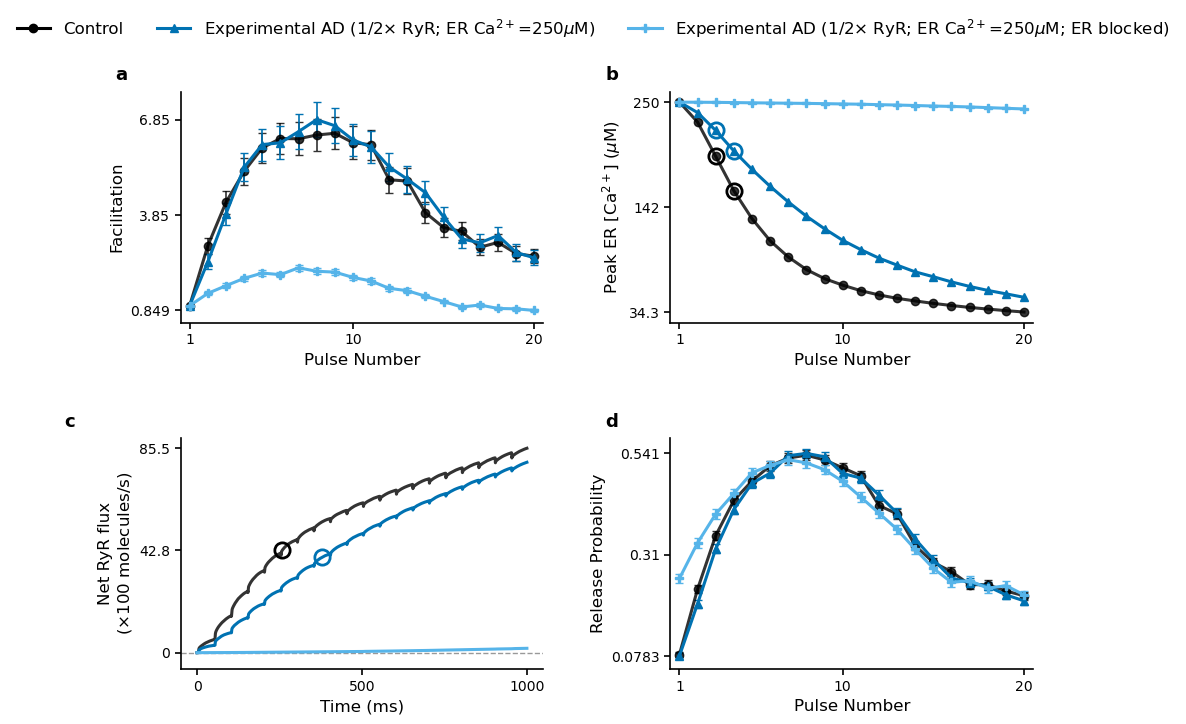

In [ ]:
# ============================================================
# FIGURE -- 4 panels, 2x2: (a) facilitation; (b) ER peak;
# (c) net RyR flux; (d) release probability. All 3 conditions overlaid.
# ============================================================

FIGSIZE = (11, 7.5)
SAVE_NAME = "/data/hdrive/phd/AD-presynaptic-calcium-model/figures/outputs/figS4_ER_hyperactivity_RyRunder250.png"

fig, axes = plt.subplots(2, 2, figsize=FIGSIZE)
fig.subplots_adjust(hspace=0.5, wspace=0.35, top=0.88)

stat_panel(
    axes[0, 0], "a", "fac_mean", "fac_sd", "Facilitation", "fac_vs_pulse",
)

trace_panel(axes[0, 1], "b", "er_peak", r"Peak ER [Ca$^{2+}$] ($\mu$M)", "er_peak")
for key in RING_MARK_CONDITIONS:
    cond = get_condition(key)
    idx = depletion_info[key]["steepest_idx"]
    axes[0, 1].plot(
        pulses[idx:idx + 2], train_data[key]["er_peak"][idx:idx + 2],
        linestyle="none", marker="o", markersize=MARKERSIZE + 5,
        markerfacecolor="none", markeredgecolor=cond.color, markeredgewidth=2,
        zorder=cond.zorder + 1,
    )

flux_trace_panel(
    axes[1, 0], "c", "ryr_flux_t_ms", "ryr_flux",
    "Net RyR flux\n" + r"($\times$100 molecules/s)", "ryr_flux",
    letter_x=-0.32, zero_line=True,
)
for key in RING_MARK_CONDITIONS:
    cond = get_condition(key)
    info = half_rise_info[key]
    axes[1, 0].plot(
        info["t_ms"], info["y"],
        linestyle="none", marker="o", markersize=MARKERSIZE + 5,
        markerfacecolor="none", markeredgecolor=cond.color, markeredgewidth=2,
        zorder=cond.zorder + 1,
    )

stat_panel(
    axes[1, 1], "d", "pr_mean", "pr_sd", "Release Probability", "pr_vs_pulse",
)

train_handles = [
    Line2D([0], [0], color=get_condition(k).color, marker=get_condition(k).marker,
           linestyle="-", markersize=MARKERSIZE, label=get_condition(k).label)
    for k in TRAIN_ORDER
]
fig.legend(
    handles=train_handles, loc="upper center", ncol=3,
    frameon=False, bbox_to_anchor=(0.5, 1.0),
)

save_figure(fig, SAVE_NAME)
plt.show()